In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
main_df = pd.read_csv('../data/inputs/application_train.csv')
prev_app_df = pd.read_csv('../data/inputs/previous_application.csv')

main_df.shape, prev_app_df.shape

((307511, 122), (1670214, 37))

In [4]:
prev_app_df.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
prev_app_df = prev_app_df.sort_values(['SK_ID_CURR', 'DAYS_DECISION'], ascending=[True, False]) \
                         .drop_duplicates('SK_ID_CURR', keep='first')

prev_app_df.shape

(338857, 37)

In [13]:
merged_df = main_df.merge(
    prev_app_df,
    how='left',
    on='SK_ID_CURR'
)
merged_df.shape

(307511, 158)

In [ ]:
import pandas as pd

merged_df['MONTH_LABEL'] = np.ceil(merged_df['DAYS_DECISION'] / 30)
merged_df['MONTH_LABEL'] = merged_df['MONTH_LABEL'].astype('Int64')
merged_df['MONTH_LABEL'] = merged_df['MONTH_LABEL'].astype(str)

print(merged_df[['DAYS_DECISION', 'MONTH_LABEL']])

        DAYS_DECISION MONTH_LABEL
0              -606.0         -20
1              -746.0         -24
2              -815.0         -27
3              -181.0          -6
4              -374.0         -12
...               ...         ...
307506         -273.0          -9
307507        -2497.0         -83
307508        -1909.0         -63
307509         -277.0          -9
307510         -171.0          -5

[307511 rows x 2 columns]


### 90 DAYS

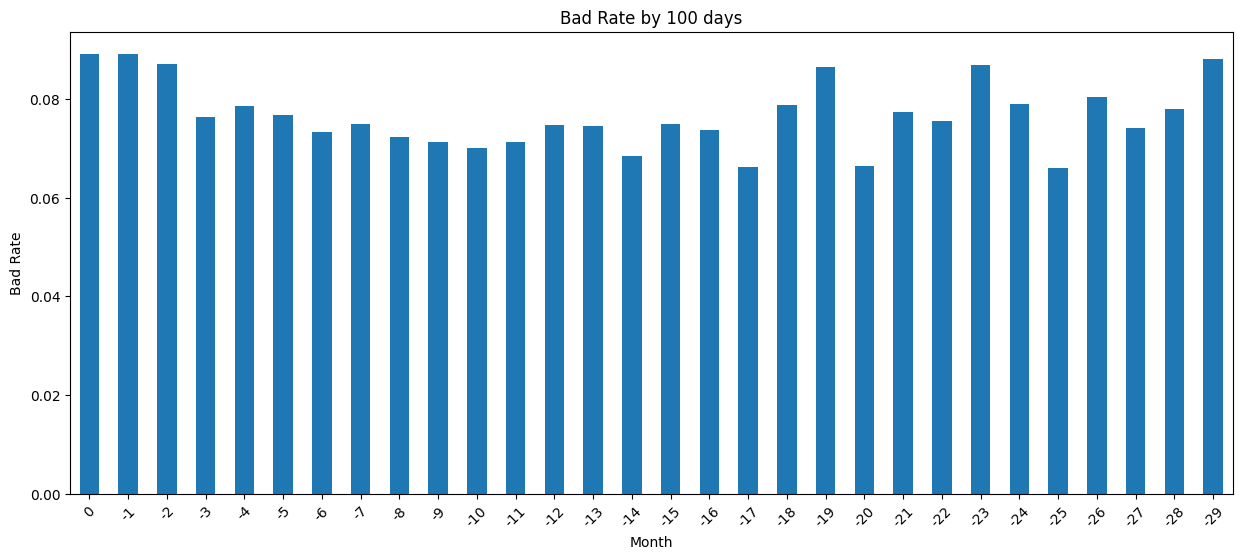

In [37]:
DAYS_TO_DEVIDE = 100

merged_df['MONTH_LABEL'] = np.ceil(merged_df['DAYS_DECISION'] / DAYS_TO_DEVIDE)
merged_df['MONTH_LABEL'] = merged_df['MONTH_LABEL'].astype('Int64')

bad_rate_by_month = merged_df.groupby('MONTH_LABEL')['TARGET'].mean().sort_index(ascending=False)

plt.figure(figsize=(15, 6))
bad_rate_by_month.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Bad Rate')
plt.title(f'Bad Rate by {DAYS_TO_DEVIDE} days')
plt.xticks(rotation=45)
plt.show()